Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.preprocessing import LabelEncoder

sns.set(style='whitegrid')

In [3]:
df = pd.read_csv('./cleaned_cafe_sales.csv')
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
0,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01
1,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01
2,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01
3,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unknown,2023-01-01
4,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01


Feature Engineering

In [8]:
# pastikan kolom tanggal dalam format datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# ekstrak fitur waktu dari kolom transaction date
df['Month'] = df['Transaction Date'].dt.month
df['DayOfWeek'] = df['Transaction Date'].dt.dayofweek # Senin=0, Minggu=6
df['DayOfMonth'] = df['Transaction Date'].dt.day
df['Hour'] = df['Transaction Date'].dt.hour

In [10]:
# label encoding untuk kolom kategori
le = LabelEncoder()
df['Item_encoded'] = le.fit_transform(df['Item'])
df['Payment Method_encoded'] = le.fit_transform(df['Payment Method'])

print('Kolom setelah ekstraksi feature engineering:')
print(df.columns.tolist())

df.head()

Kolom setelah ekstraksi feature engineering:
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Transaction Date', 'Month', 'DayOfWeek', 'DayOfMonth', 'Hour', 'Item_encoded', 'Payment Method_encoded']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date,Month,DayOfWeek,DayOfMonth,Hour,Item_encoded,Payment Method_encoded
0,TXN_6234882,2,4.000000,1.000000,4.000000,1,2023-01-01,1,6,1,0,2,1
1,TXN_4801947,3,1.000000,3.000000,3.000000,2,2023-01-01,1,6,1,0,3,2
2,TXN_8842223,5,5.000000,2.951766,14.758828,2,2023-01-01,1,6,1,0,5,2
3,TXN_5728991,4,3.029846,5.000000,15.149228,3,2023-01-01,1,6,1,0,4,3
4,TXN_2192787,5,5.000000,4.000000,20.000000,0,2023-01-01,1,6,1,0,5,0


Feature Selection - Method 1 : Pearson Correlation

In [12]:
# Pilih Kolom numerik untuk analisis korelasi
numeric_features = ['Quantity', 'Price Per Unit', 'Total Spent',
                    'Month', 'DayOfWeek', 'DayOfMonth', 'Item_encoded', 'Payment Method_encoded']

df_numeric = df[numeric_features]
df_numeric.corr()

# Hitung korelasi matriks
corr_matrix = df_numeric.corr(method='pearson')

print("Matriks Korelasi Pearson:")
corr_matrix.round(3)


Matriks Korelasi Pearson:


,Quantity,Price Per Unit,Total Spent,Month,DayOfWeek,DayOfMonth,Item_encoded,Payment Method_encoded
Quantity,1.000,0.002,0.706,-0.004,0.001,-0.007,0.006,-0.006
Price Per Unit,0.002,1.000,0.644,-0.013,-0.001,0.021,0.228,-0.023
Total Spent,0.706,0.644,1.000,-0.006,0.004,0.005,0.152,-0.019
Month,-0.004,-0.013,-0.006,1.000,0.018,0.001,-0.007,-0.011
DayOfWeek,0.001,-0.001,0.004,0.018,1.000,-0.008,-0.009,0.001
DayOfMonth,-0.007,0.021,0.005,0.001,-0.008,1.000,0.015,-0.005
Item_encoded,0.006,0.228,0.152,-0.007,-0.009,0.015,1.000,0.002
Payment Method_encoded,-0.006,-0.023,-0.019,-0.011,0.001,-0.005,0.002,1.000


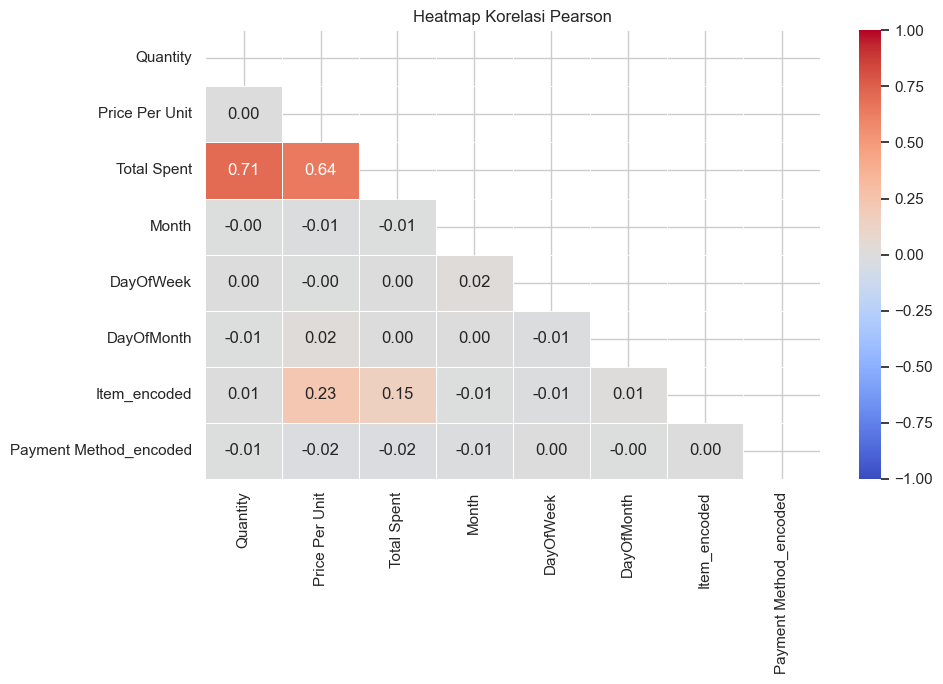

In [ ]:
# Visualisasi heatmap korelasi
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Sembunyikan segitiga atas

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, mask=mask, linewidths=0.5, vmin=-1, vmax=1)

plt.title('Heatmap Korelasi Pearson')
plt.tight_layout()
plt.show()

In [14]:
# Korelasi setiap fitur terhadap target 'Total Spent'
target = 'Total Spent'
corr_with_target = (
    df_numeric.corr(method='pearson')[target]
    .drop(target)  # Hapus korelasi dengan dirinya sendiri
    .sort_values(key=abs, ascending=False)
)

print(f"Korelasi setiap fitur terhadap '{target}':")
print(corr_with_target.to_string())

Korelasi setiap fitur terhadap 'Total Spent':
Quantity                  0.705991
Price Per Unit            0.644480
Item_encoded              0.151638
Payment Method_encoded   -0.019353
Month                    -0.005859
DayOfMonth                0.004627
DayOfWeek                 0.004408


In [17]:
# Seleksi fitur berdasarkan treshold korelasi
threshold = 0.1

select_by_pearson = corr_with_target[abs(corr_with_target) >= threshold].index.tolist()
dropped_by_pearson = corr_with_target[abs(corr_with_target) < threshold].index.tolist()

print(f'Treshold korelasi: |r| >= {threshold}')
print(f'Fitur yang dipilih: {select_by_pearson}')
print(f'Fitur yang di-drop: {dropped_by_pearson}')

Treshold korelasi: |r| >= 0.1
Fitur yang dipilih: ['Quantity', 'Price Per Unit', 'Item_encoded']
Fitur yang di-drop: ['Payment Method_encoded', 'Month', 'DayOfMonth', 'DayOfWeek']


Method 2 : Kbest

In [18]:
X = df_numeric.drop(columns=['Total Spent'])
y = df_numeric['Total Spent']

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Shape X: (8613, 7)
Shape y: (8613,)


In [23]:
# Hitung F-score dan p-value untuk setiap fitur
selector_all = SelectKBest(score_func=f_regression, k='all')
selector_all.fit(X, y)

# Buat DataFrame Ringkasan
skb_results = pd.DataFrame({
    'Feature': X.columns, # Corrected: Use X.columns to get feature names
    'F-score': selector_all.scores_,
    'p-value': selector_all.pvalues_
})

# Tandai signifikan (p-value < 0.05)
skb_results['Signifikan'] = skb_results['p-value'].apply(lambda p: 'Ya' if p < 0.05 else 'Tidak')

print('Skor selectKBest (F-regression) - semua fitur:')
skb_results.round(4)

Skor selectKBest (F-regression) - semua fitur:


,Feature,F-score,p-value,Signifikan
0,Quantity,8556.8652,0.0000,Ya
1,Price Per Unit,6117.5863,0.0000,Ya
2,Month,0.2956,0.5867,Tidak
3,DayOfWeek,0.1673,0.6825,Tidak
4,DayOfMonth,0.1844,0.6677,Tidak
5,Item_encoded,202.6626,0.0000,Ya
6,Payment Method_encoded,3.2265,0.0725,Tidak


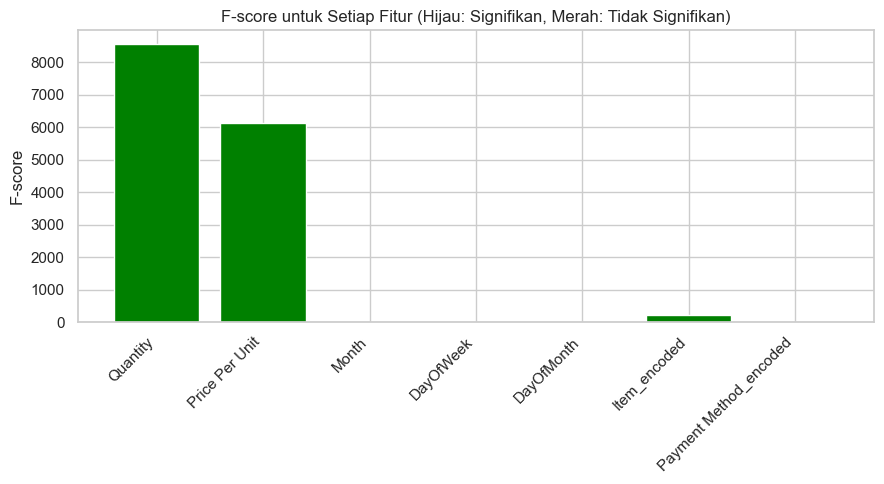

In [25]:
# Visualisasi F-score
plt.figure(figsize=(9, 5))

bar_colors = ['green' if p < 0.05 else 'red' for p in skb_results['p-value']]

plt.bar(skb_results['Feature'], skb_results['F-score'], color=bar_colors)
plt.xticks(rotation=45, ha='right')
plt.title('F-score untuk Setiap Fitur (Hijau: Signifikan, Merah: Tidak Signifikan)')
plt.ylabel('F-score')

plt.tight_layout()
plt.show()

In [26]:
# Pilih k terbaik berdasarkan F-score
k = 4

selector_k = SelectKBest(score_func=f_regression, k=k)
X_selected = selector_k.fit_transform(X, y)

# Nama Fitur yang dipilih
selected_mask = selector_k.get_support()
selected_features = [col for col, selected in zip(X.columns, selected_mask) if selected]
dropped_features = [col for col, selected in zip(X.columns, selected_mask) if not selected]

print(f'Fitur yang dipilih (k={k}): {selected_features}')
print(f'Fitur yang di-drop (k={k}): {dropped_features}')

Fitur yang dipilih (k=4): ['Quantity', 'Price Per Unit', 'Item_encoded', 'Payment Method_encoded']
Fitur yang di-drop (k=4): ['Month', 'DayOfWeek', 'DayOfMonth']


In [30]:
# Buat Dataframe Ringkasan untuk k terbaik
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
X_selected_df['Total Spent'] = y.values

print("Dataset setelah SelectKBest:")
display(X_selected_df.head(10))

Dataset setelah SelectKBest:


,Quantity,Price Per Unit,Item_encoded,Payment Method_encoded,Total Spent
0,4.000000,1.000000,2.0,1.0,4.000000
1,1.000000,3.000000,3.0,2.0,3.000000
2,5.000000,2.951766,5.0,2.0,14.758828
3,3.029846,5.000000,4.0,3.0,15.149228
4,5.000000,4.000000,5.0,0.0,20.000000
5,2.000000,2.000000,1.0,0.0,4.000000
6,4.000000,3.000000,0.0,0.0,12.000000
7,2.000000,4.000000,6.0,2.0,8.000000
8,4.000000,2.000000,1.0,2.0,8.000000
9,5.000000,1.500000,7.0,3.0,7.500000


Perbandingan hasil seleksi fitur antara kedua metode:

In [31]:
comparison = pd.DataFrame({
    'Fitur': X.columns,
    'Pearson r': [abs(corr_with_target.get(f, 0)) for f in X.columns],
    'Pearson Dipilih': ['Dipilih' if f in selected_features else 'Tidak' for f in X.columns],
    'F-Score': selector_all.scores_,
    'P-Value': selector_all.pvalues_,
    'SelectKBest': ['Dipilih' if f in selected_features else 'Tidak' for f in X.columns],
})

comparison = comparison.sort_values(by='F-Score', ascending=False)

print("\nPerbandingan Pearson vs SelectKBest:")
display(comparison)


Perbandingan Pearson vs SelectKBest:


,Fitur,Pearson r,Pearson Dipilih,F-Score,P-Value,SelectKBest
0,Quantity,0.705991,Dipilih,8556.865196,0.000000e+00,Dipilih
1,Price Per Unit,0.644480,Dipilih,6117.586264,0.000000e+00,Dipilih
5,Item_encoded,0.151638,Dipilih,202.662646,1.793590e-45,Dipilih
6,Payment Method_encoded,0.019353,Dipilih,3.226460,7.249219e-02,Dipilih
2,Month,0.005859,Tidak,0.295613,5.866601e-01,Tidak
4,DayOfMonth,0.004627,Tidak,0.184359,6.676646e-01,Tidak
3,DayOfWeek,0.004408,Tidak,0.167326,6.825092e-01,Tidak


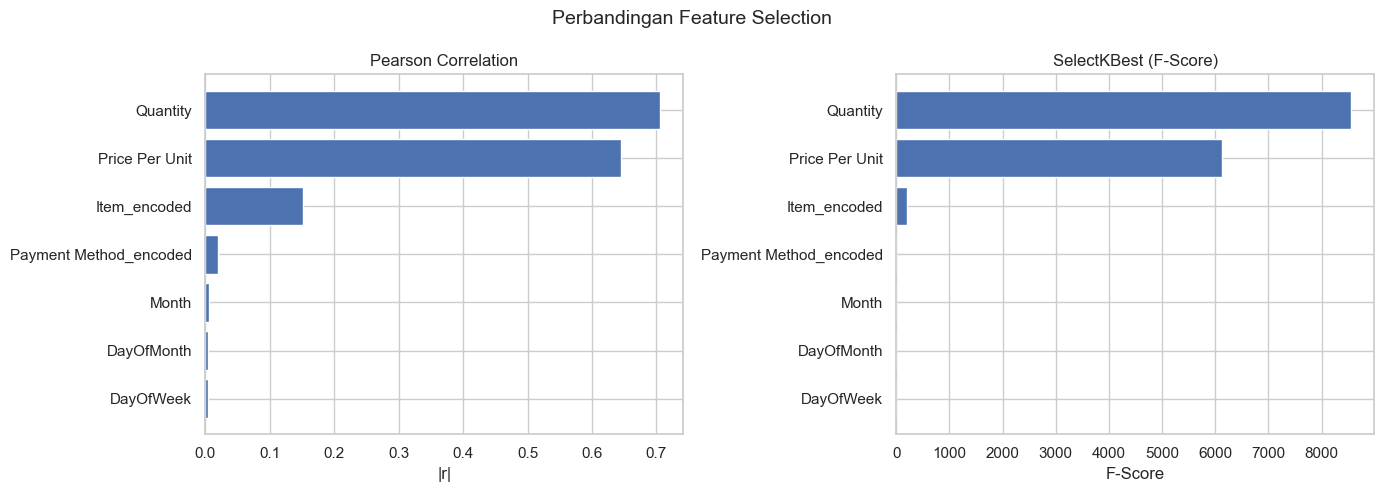

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Feature Selection', fontsize=14)

# --- Pearson Correlation ---
pearson_sorted = comparison.sort_values('Pearson r')

axes[0].barh(
    pearson_sorted['Fitur'],
    pearson_sorted['Pearson r']
)

axes[0].set_title('Pearson Correlation')
axes[0].set_xlabel('|r|')

# --- SelectKBest ---
skb_sorted = comparison.sort_values('F-Score')

axes[1].barh(
    skb_sorted['Fitur'],
    skb_sorted['F-Score']
)

axes[1].set_title('SelectKBest (F-Score)')
axes[1].set_xlabel('F-Score')

plt.tight_layout()
plt.show()

In [33]:
file_name = "featured_cafe_sales.csv"
X_selected_df.to_csv(file_name, index=False)

print(f"\nDataset berhasil disimpan: {file_name}")
print(f"Fitur terpilih: {list(X_selected_df.columns)}")
print(f"Jumlah data: {len(X_selected_df)}")


Dataset berhasil disimpan: featured_cafe_sales.csv
Fitur terpilih: ['Quantity', 'Price Per Unit', 'Item_encoded', 'Payment Method_encoded', 'Total Spent']
Jumlah data: 8613
